In [1]:
import functools
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

from network import Net, NetDiscovery
from diff_equations import grad, grinding_kinetics

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sns.set_theme()
torch.manual_seed(42)

Text(0.5, 0, 'Time (s)')

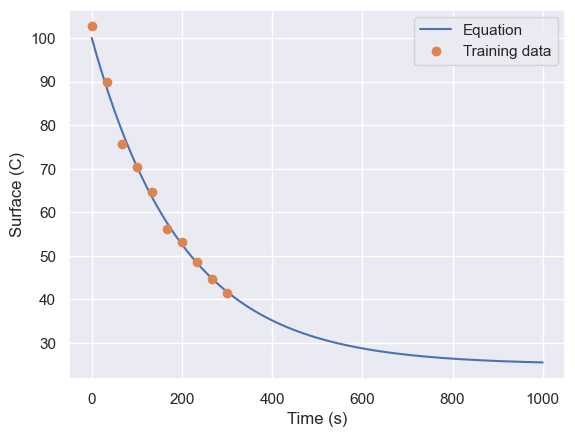

In [4]:
np.random.seed(10)

Smax = 25
S0 = 100
k = 0.005
times = np.linspace(0, 1000, 1000)
eq = functools.partial(grinding_kinetics, Smax=Smax, S0=S0, k=k)
surfaces = eq(times)

# Make training data
t = np.linspace(0, 300, 10)
S = eq(t) +  2 * np.random.randn(10)

plt.plot(times, surfaces)
plt.plot(t, S, 'o')
plt.legend(['Equation', 'Training data'])
plt.ylabel('Surface (C)')
plt.xlabel('Time (s)')

Vanilla network

Epoch 0/20000, loss: 4622.79
Epoch 2000/20000, loss: 2478.87
Epoch 4000/20000, loss: 1820.89
Epoch 6000/20000, loss: 241.73
Epoch 8000/20000, loss: 3.07
Epoch 10000/20000, loss: 2.40
Epoch 12000/20000, loss: 2.28
Epoch 14000/20000, loss: 2.18
Epoch 16000/20000, loss: 2.04
Epoch 18000/20000, loss: 1.91


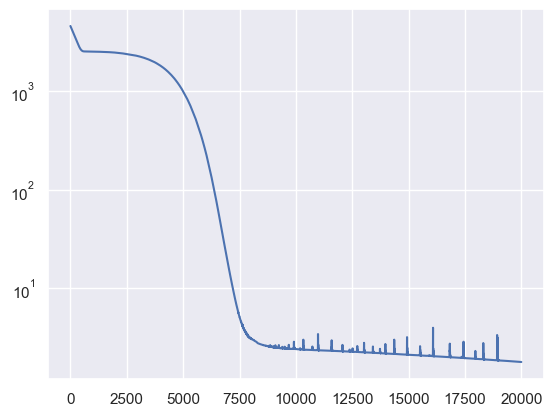

In [5]:
net = Net(1,1, loss2=None, epochs=20000, lr=1e-5).to(DEVICE)

losses = net.fit(t, S)

plt.plot(losses)
plt.yscale('log')

In [6]:
def l2_reg(model: torch.nn.Module):
    return torch.sum(sum([p.pow(2.) for p in model.parameters()]))

Epoch 0/20000, loss: 12291.20
Epoch 2000/20000, loss: 4397.21
Epoch 4000/20000, loss: 2647.45
Epoch 6000/20000, loss: 1668.27
Epoch 8000/20000, loss: 1197.68
Epoch 10000/20000, loss: 979.97
Epoch 12000/20000, loss: 858.40
Epoch 14000/20000, loss: 766.00
Epoch 16000/20000, loss: 683.16
Epoch 18000/20000, loss: 609.67


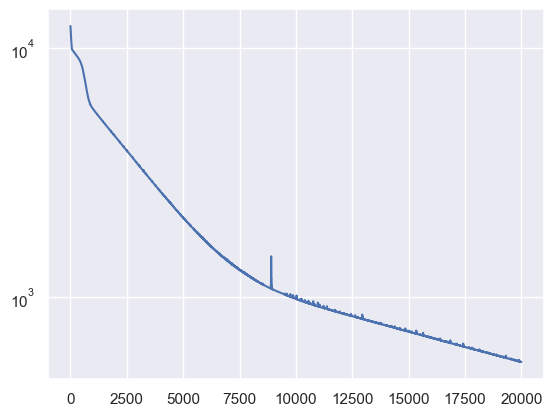

In [7]:
netreg = Net(1,1, loss2=l2_reg, epochs=20000, lr=1e-4, loss2_weight=1).to(DEVICE)

losses = netreg.fit(t, S)

plt.plot(losses)
plt.yscale('log')

Text(0.5, 0, 'Time (s)')

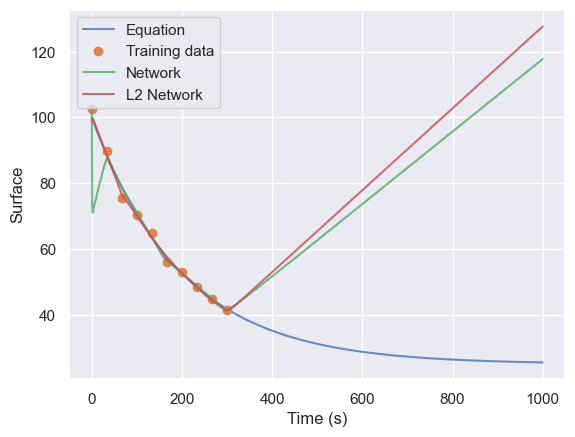

In [8]:
predsreg = netreg.predict(times)

preds = net.predict(times)
plt.plot(times, surfaces, alpha=0.8)
plt.plot(t, S, 'o')
plt.plot(times, preds, alpha=0.8)
plt.plot(times, predsreg, alpha=0.8)

plt.legend(labels=['Equation','Training data', 'Network', 'L2 Network'])
plt.ylabel('Surface')
plt.xlabel('Time (s)')

## PINN

In [9]:
def physics_loss(model: torch.nn.Module):
    ts = torch.linspace(0, 1000, steps=1000,).view(-1,1).requires_grad_(True).to(DEVICE)
    surfaces = model(ts)
    dS = grad(surfaces, ts)[0]
    pde = k*(Smax - surfaces) - dS
    
    return torch.mean(pde**2)

Epoch 0/30000, loss: 4816.04
Epoch 3000/30000, loss: 2379.89
Epoch 6000/30000, loss: 452.64
Epoch 9000/30000, loss: 1.51
Epoch 12000/30000, loss: 1.00
Epoch 15000/30000, loss: 0.77
Epoch 18000/30000, loss: 0.50
Epoch 21000/30000, loss: 0.27
Epoch 24000/30000, loss: 0.14
Epoch 27000/30000, loss: 0.10


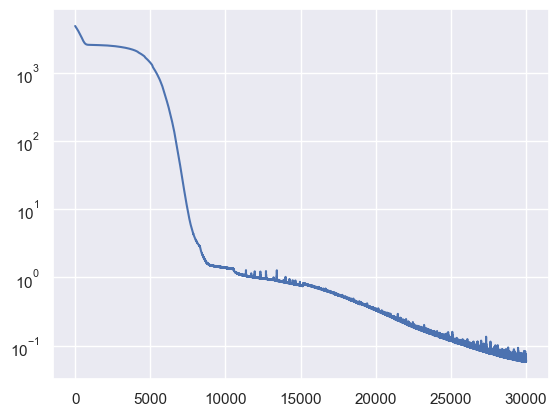

In [10]:
net = Net(1,1, loss2=physics_loss, epochs=30000, loss2_weight=1, lr=1e-5).to(DEVICE)

losses = net.fit(t, S)
plt.plot(losses)
plt.yscale('log')

Text(0.5, 0, 'Время (s)')

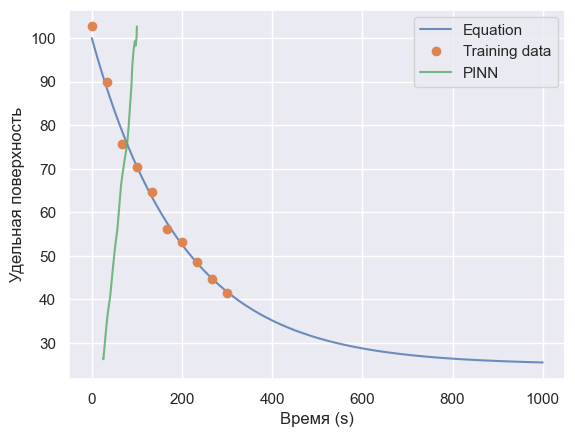

In [16]:
preds = net.predict(times)

plt.plot(times, surfaces, alpha=0.8)
plt.plot(t, S, 'o')
plt.plot(surfaces, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'PINN'])
plt.ylabel('Удельная поверхность')
plt.xlabel('Время (s)')

## Parameter discovery

In [ ]:
import importlib
import sys



<module 'network' from 'c:\\Users\\anna\\Desktop\\itmo\\nir\\PINN\\src\\network.py'>

In [25]:
importlib.reload(sys.modules['network'])
from network import NetDiscovery

для случая, когда не знаем k

In [26]:
def physics_loss_discovery(model: torch.nn.Module):
    ts = torch.linspace(0, 1000, steps=1000,).view(-1,1).requires_grad_(True).to(DEVICE)
    surfaces = model(ts)
    dS = grad(surfaces, ts)[0]
    pde = model.k * (Smax - surfaces) - dS
    
    return torch.mean(pde**2)

Epoch 0/40000, loss: 4542.46
Epoch 4000/40000, loss: 2522.47
Epoch 8000/40000, loss: 2218.91
Epoch 12000/40000, loss: 365.50
Epoch 16000/40000, loss: 1.64
Epoch 20000/40000, loss: 0.77
Epoch 24000/40000, loss: 0.57
Epoch 28000/40000, loss: 0.37
Epoch 32000/40000, loss: 0.26
Epoch 36000/40000, loss: 0.21


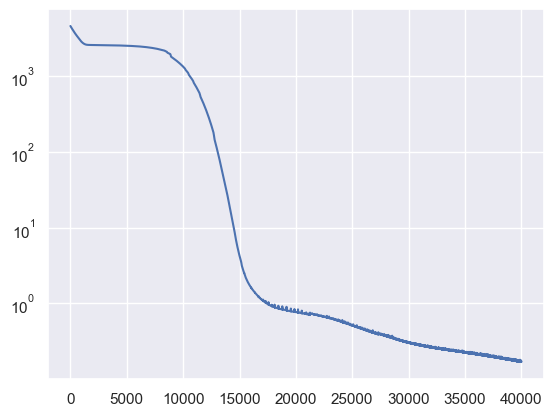

In [27]:
netdisc = NetDiscovery(1, 1, loss2=physics_loss_discovery, loss2_weight=1, epochs=40000, lr= 5e-6).to(DEVICE)

losses = netdisc.fit(t, S)
plt.plot(losses)
plt.yscale('log')

Parameter containing:
tensor([0.0052], requires_grad=True)


Text(0.5, 0, 'Время (s)')

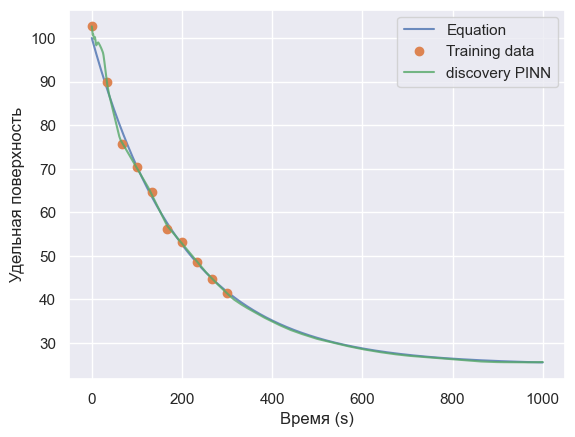

In [29]:
preds = netdisc.predict(times)
print(netdisc.k)

plt.plot(times, surfaces, alpha=0.8)
plt.plot(t, S, 'o')
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'discovery PINN'])
plt.ylabel('Удельная поверхность')
plt.xlabel('Время (s)')